In [1]:
import sys
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [2]:
import pandas as pd

TEXTUAL_EMBEDDINGS_PATH = '../../../../data/textual_features/'

text_emb_128 = TEXTUAL_EMBEDDINGS_PATH + 'textual_embeddings_64.parquet'

df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.246657,0.013422,0.030803,-0.027900,0.031794,0.008041,...,0.005594,-0.024074,-0.018304,0.053269,-0.010537,0.015129,0.081555,-0.040338,0.035150,0.022799
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.180983,0.008709,-0.045347,0.040739,0.131509,-0.015846,...,-0.009488,0.010030,0.005332,-0.000430,0.039798,0.000698,0.001728,0.016241,0.015980,0.004910
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,0.077558,0.011321,-0.032596,-0.091188,0.033407,-0.025912,0.008252,0.035297,0.028148,0.000140
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,0.031245,0.020799,0.052592,0.052332,-0.035168,0.025643,0.025552,0.038130,0.078260,-0.080680
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,-0.064555,-0.034023,-0.025314,-0.018282,-0.022678,0.025053,0.034170,-0.035683,-0.019101,-0.014827


(2950135, 260)


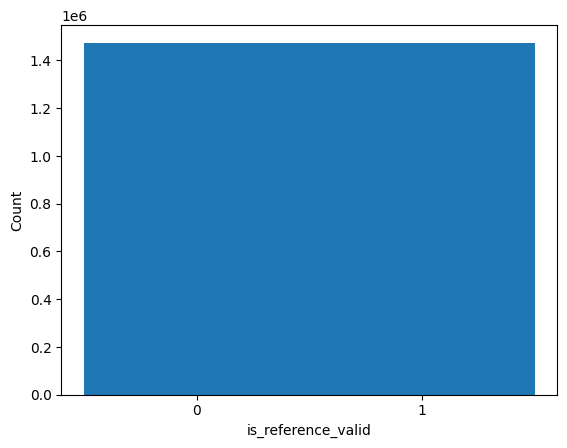

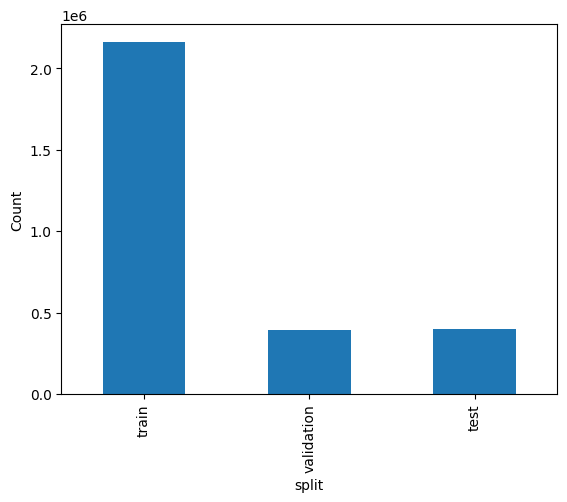

In [3]:
plt.hist(df["is_reference_valid"], bins=[-0.5, 0.5, 1.5])
plt.xticks([0, 1])
plt.xlabel("is_reference_valid")
plt.ylabel("Count")
plt.show()

# `split` is categorical, so a bar chart is clearer than a numeric histogram.
split_counts = df["split"].astype(str).str.lower().value_counts()
split_counts = split_counts.reindex(["train", "validation", "val", "test"]).dropna()
split_counts.plot(kind="bar")
plt.xlabel("split")
plt.ylabel("Count")
plt.show()

In [4]:
X = df.drop(columns=["is_reference_valid", "article_id", "ref_id", "vector_text_article", "vector_text_ref"], errors="ignore").copy()
y = df["is_reference_valid"].copy()

split_series = X["split"].astype(str).str.lower()
max_rows = len(X)  # Default to using all rows if the dataset is small
random_state = 42

train_idx = X.index[split_series == "train"]
test_idx = X.index[split_series == "test"]
val_idx = X.index[split_series.isin(["validation", "val"])]

# Random sampling avoids taking a contiguous block that may contain a single class.
train_idx = train_idx.to_series().sample(n=min(max_rows, len(train_idx)), random_state=random_state).index
test_idx = test_idx.to_series().sample(n=min(max_rows, len(test_idx)), random_state=random_state).index
val_idx = val_idx.to_series().sample(n=min(max_rows, len(val_idx)), random_state=random_state).index

X_train = X.loc[train_idx].drop(columns=["split"], errors="ignore")
y_train = y.loc[train_idx]
X_test = X.loc[test_idx].drop(columns=["split"], errors="ignore")
y_test = y.loc[test_idx]
X_val = X.loc[val_idx].drop(columns=["split"], errors="ignore")
y_val = y.loc[val_idx]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print("Feature rows:", len(X))
print("Global label distribution:")
print(y.value_counts(normalize=True))
print("\nSplit sizes:", {"train": len(X_train), "test": len(X_test), "val": len(X_val)})
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))
print("\nVal label distribution:")
print(y_val.value_counts(normalize=True))

del df, X, y, split_series, X_train, X_test, X_val

Feature rows: 2950135
Global label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64

Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}

Train label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64

Test label distribution:
is_reference_valid
1    0.500003
0    0.499997
Name: proportion, dtype: float64

Val label distribution:
is_reference_valid
0    0.5
1    0.5
Name: proportion, dtype: float64


In [5]:
y_train.value_counts()

is_reference_valid
1    1081260
0    1081253
Name: count, dtype: int64

In [6]:
from xgboost import XGBClassifier

# modello GPU
model = XGBClassifier(
    tree_method="hist",   # obbligatorio
    device="cuda"        # usa GPU
)

model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [7]:
from sklearn.model_selection import RandomizedSearchCV
import gc

# Valid hyperparameters for XGBClassifier
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1, 2, 5],
}

# On Windows, process-based CV workers can crash with large arrays/GPU contexts.
# Keep CV itself single-process to avoid TerminatedWorkerError.
search_n_jobs = 1

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=2,
    scoring="f1",
    random_state=42,
    n_jobs=search_n_jobs,
    pre_dispatch=search_n_jobs,
    error_score="raise",
    verbose=2,
)

# Run randomized search on the validation split (kept small by earlier sampling)
random_search.fit(X_val_scaled, y_val)

Fitting 2 folds for each of 20 candidates, totalling 40 fits


/home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/env/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [00:32:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  13.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  13.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, reg_lambda=10, scale_pos_weight=5, subsample=0.8; total time=   2.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, reg_lambda=10, scale_pos_weight=5, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=500, reg_lambda=5, scale_pos_weight=2, subsample=1.0; total time=   3.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=500, reg_lambda=5, scale_pos_weight=2, subsample=1.0; total time=   3.3s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=500, reg_lambda=10, s

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [10]:
import sys
import os
from pathlib import Path

from utils.textual_utils.registry.model_saver import LocalModelRegistry

tmp_path = '../../../../../tmp/model_registry'
registry = LocalModelRegistry(registry_base_path=str(tmp_path))

p = best_params if 'best_params' in globals() else {}
m = best_model if 'best_model' in globals() else model

n = p.get('n_estimators', p.get('n_neighbors', 'default'))
model_name_to_save = f"model_n{n}"

run_dir = registry.save_experiment(
    model_name=model_name_to_save,
    model=m,
    params=p,
    metrics={
        "scoring": "f1_weighted",
        "max_tuning_samples": int(max_tuning_samples) if 'max_tuning_samples' in globals() else 0,
    },
    dataset_info={"df_name": df_name if 'df_name' in globals() else "unknown"}
)

print(f"✅ Salvato con successo in: {run_dir}")

✅ Artefatto modello salvato con successo in: ../../../../../tmp/model_registry/model_ndefault/20260425_004756_51928c66
✅ Salvato con successo in: ../../../../../tmp/model_registry/model_ndefault/20260425_004756_51928c66


Best hyperparameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 10, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
              precision    recall  f1-score   support

           0     0.8292    0.8635    0.8460    198189
           1     0.8576    0.8222    0.8395    198191

    accuracy                         0.8429    396380
   macro avg     0.8434    0.8429    0.8428    396380
weighted avg     0.8434    0.8429    0.8428    396380



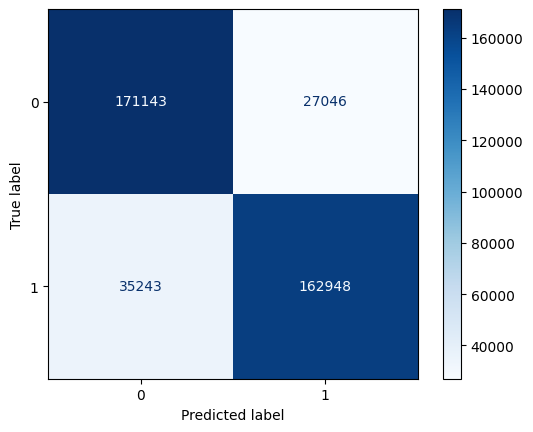

In [12]:
best_model = random_search.best_estimator_
best_params = random_search.best_params_
print("Best hyperparameters:", best_params)

y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues")